<a href="https://www.kaggle.com/code/ghadaelfeki/notebookbreast-cancer-ml-project-gh?scriptVersionId=342433976" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

##############################################################
#  MACHINE LEARNING ANALYSIS FOR
# Breast Cancer Classification
##############################################################
Breast Cancer Prediction Using Machine Learning

## Project Overview

This project develops a machine learning model to predict the survival status of breast cancer patients based on demographic, clinical, and tumor-related characteristics. The primary objective is to compare several classification algorithms and identify the model that provides the highest predictive performance. The workflow includes data preprocessing, exploratory data analysis (EDA), feature engineering, class imbalance handling using SMOTE, model training, hyperparameter tuning, and performance evaluation using standard classification metrics.

## Dataset Description:-
[https://www.kaggle.com/datasets/reihanenamdari/breast-cancer]

The dataset, Breast_Cancer.csv, contains patient records with demographic information, tumor characteristics, treatment-related features, and survival outcomes. It includes both numerical and categorical variables such as age, race, marital status, tumor stage, lymph node information, hormone receptor status, tumor size, and survival months. The target variable is Status, which indicates whether a patient is Alive or Dead.

## Project Objectives

Preprocess and clean the breast cancer dataset.
Perform exploratory data analysis to understand feature distributions and relationships.
Encode categorical variables and handle missing values.
Address class imbalance using the Synthetic Minority Over-sampling Technique (SMOTE).
Train and compare multiple machine learning classifiers, including Logistic Regression, Decision Tree, Random Forest, Support Vector Machine (SVM), K-Nearest Neighbors (KNN), and Gradient Boosting.
Optimize model performance through hyperparameter tuning and cross-validation.
Evaluate models using Accuracy, Precision, Recall, F1-score, ROC-AUC, Confusion Matrix, and ROC Curve.
Identify the most influential features contributing to breast cancer survival prediction.

## Expected Outcome

The project aims to develop a reliable predictive model that can assist in identifying patients at higher risk based on their clinical characteristics. By comparing multiple machine learning algorithms and evaluating them using comprehensive performance metrics, the study identifies the most suitable model for breast cancer outcome prediction. The findings may support clinical decision-making and demonstrate the application of machine learning techniques in healthcare analytics.

## Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

import joblib


##############################################################
# LOAD DATA
##############################################################

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ghadaelfeki/breast-cancer-ml-project-gh/Breast_Cancer.csv")

## Display the Data

In [3]:
df.head()


,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [4]:
df.tail()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
4019,62,Other,Married,T1,N1,IIA,Moderately differentiated,2,Regional,9,Positive,Positive,1,1,49,Alive
4020,56,White,Divorced,T2,N2,IIIA,Moderately differentiated,2,Regional,46,Positive,Positive,14,8,69,Alive
4021,68,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,22,Positive,Negative,11,3,69,Alive
4022,58,Black,Divorced,T2,N1,IIB,Moderately differentiated,2,Regional,44,Positive,Positive,11,1,72,Alive
4023,46,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,30,Positive,Positive,7,2,100,Alive


In [5]:
df.shape

(4024, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

In [7]:
df.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


##############################################################
# Check and REMOVE DUPLICATES
##############################################################

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df.drop_duplicates(inplace=True)

##############################################################
## CHECK MISSING VALUES
##############################################################

In [10]:
df.isnull().sum()

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

In [11]:
df.columns

Index(['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months', 'Status'],
      dtype='object')

### Exploratory Data Analysis (EDA)
## Class Distribution

In [12]:
target = df.columns[-1]
print(f"The automatically detected target column is: {target}")
print(df[target].value_counts())

The automatically detected target column is: Status
Status
Alive    3407
Dead      616
Name: count, dtype: int64


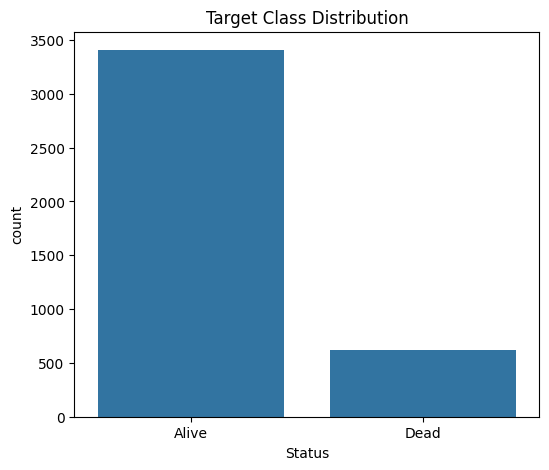

Status
Alive    3407
Dead      616
Name: count, dtype: int64


In [13]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Status"
)

plt.title("Target Class Distribution")

plt.show()

print(df["Status"].value_counts())

## Numerical Feature Histograms

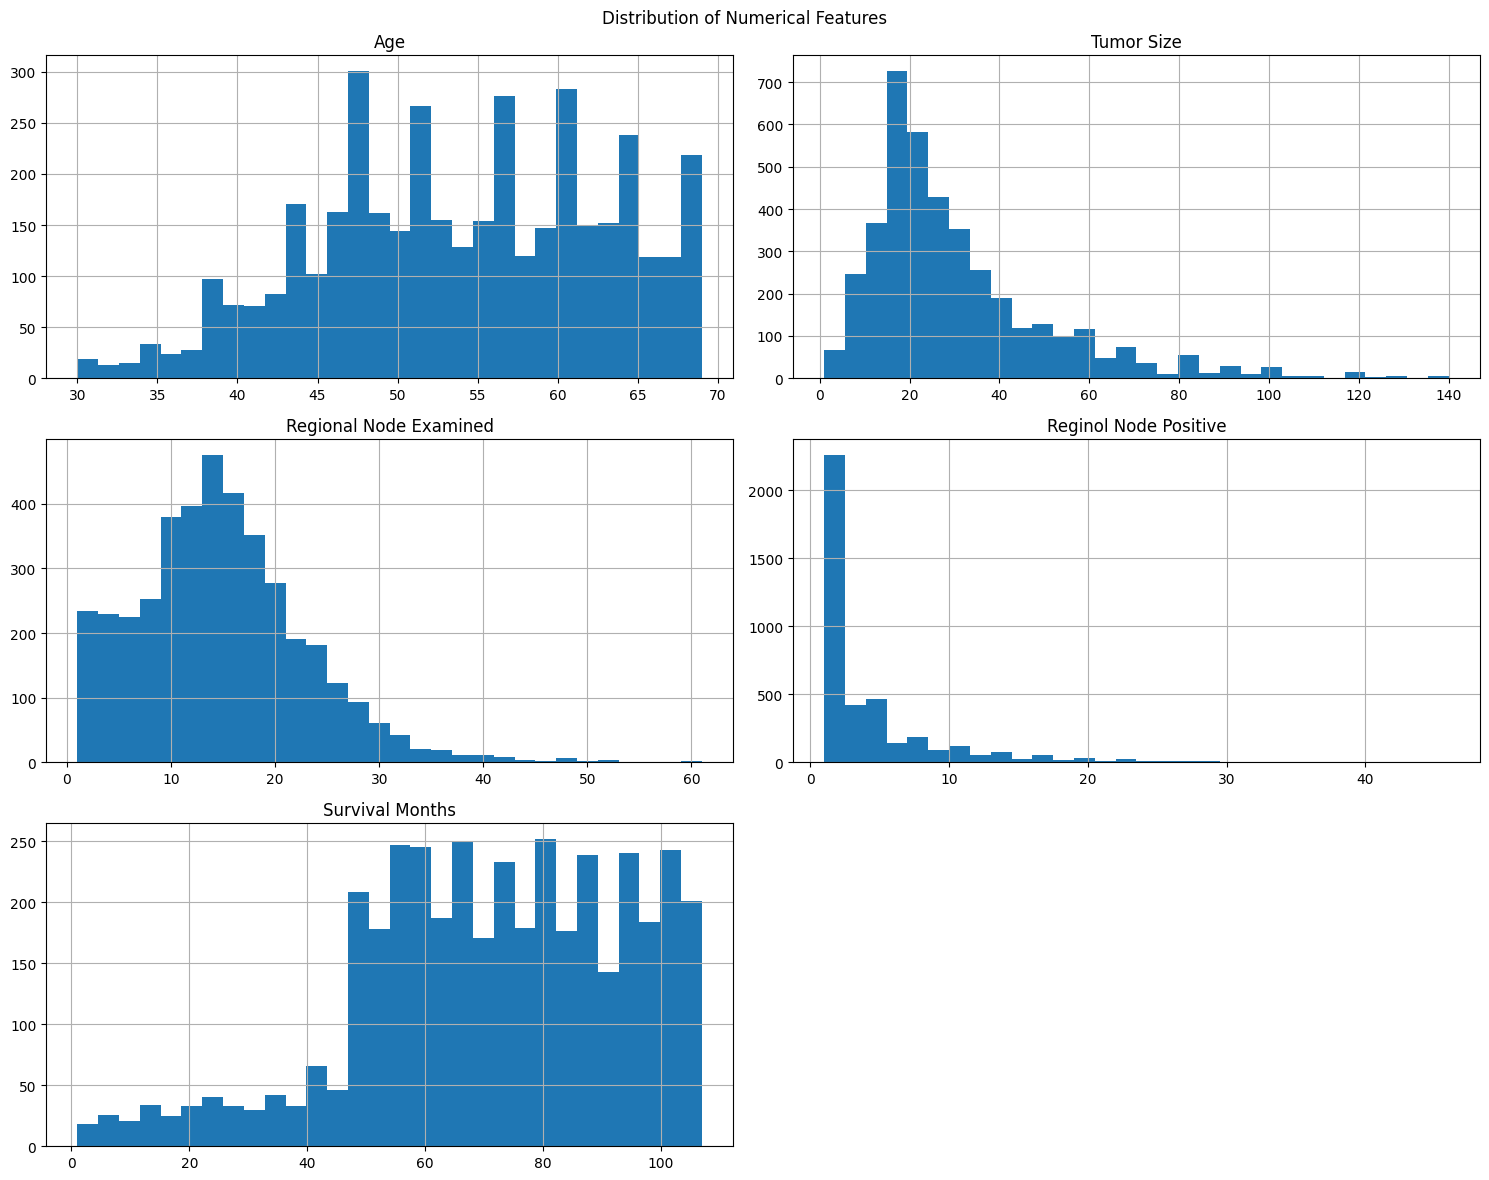

In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(
    figsize=(15,12),
    bins=30
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()


## Correlation Heatmap
This heatmap helps identify highly correlated numerical variables, which can reveal redundancy or multicollinearity before modeling.

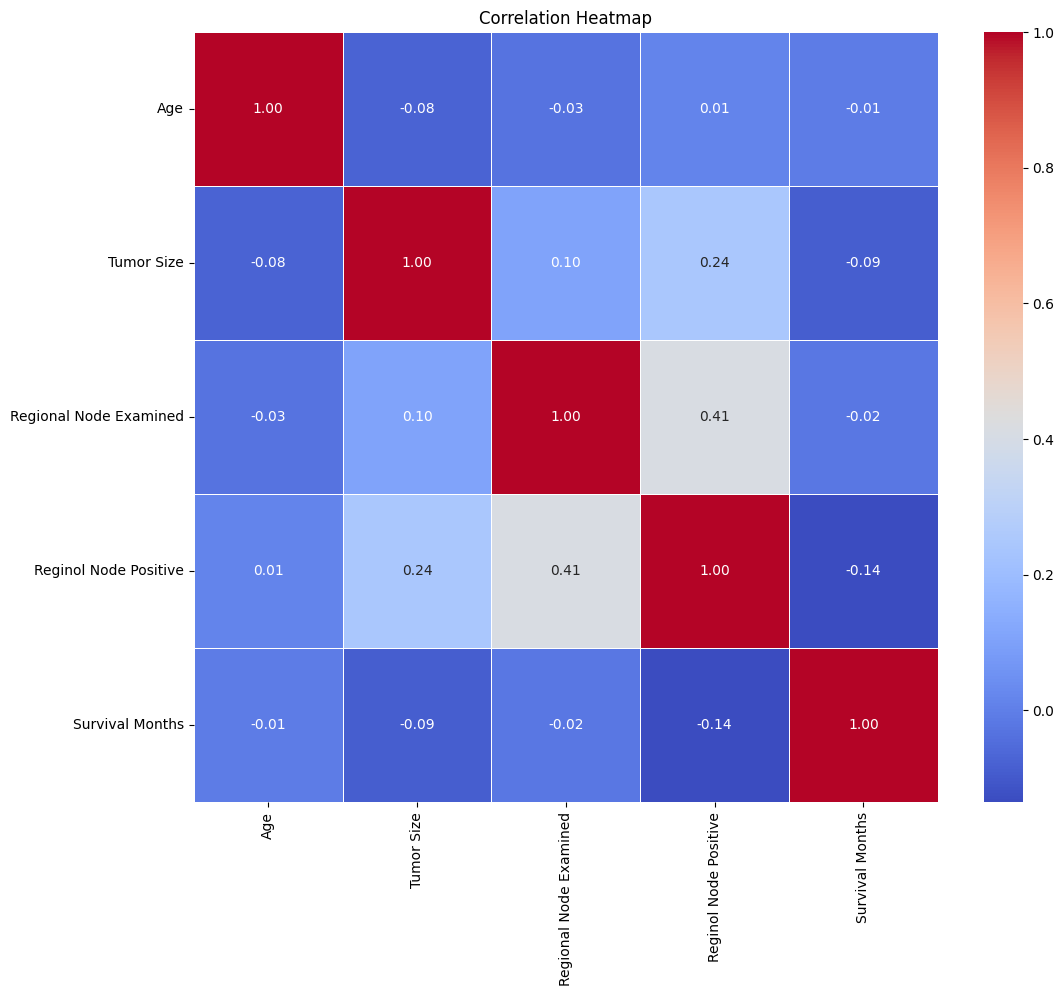

In [15]:
plt.figure(figsize=(12,10))

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")


plt.show()


## Pairplot

### Since plotting every variable is clusttered, use only the most informative numeric features.
This allows you to visually compare feature relationships across the outcome classes.

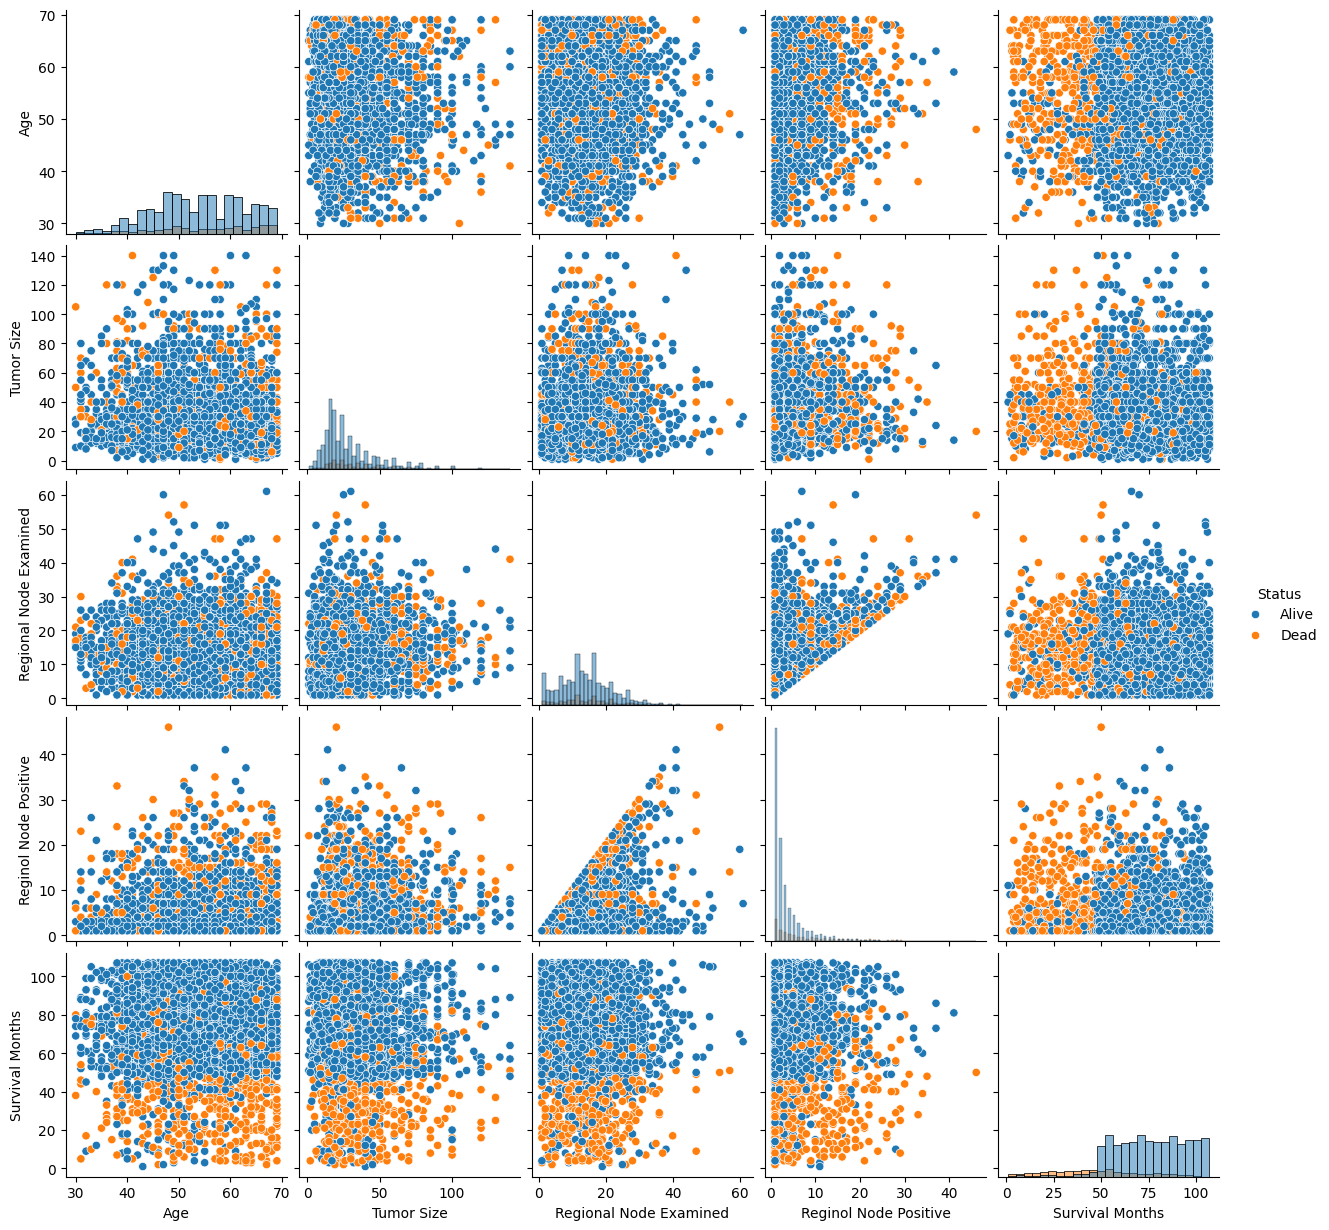

In [16]:
selected_features = [
    "Age",
    "Tumor Size",
    "Regional Node Examined",
    "Reginol Node Positive",
    "Survival Months",
    "Status"
]

sns.pairplot(
    df[selected_features],
    hue="Status",
    diag_kind="hist"
)

plt.show()


## Boxplots for Outlier Detection
Boxplots highlight observations outside the whiskers, which may represent potential outliers.

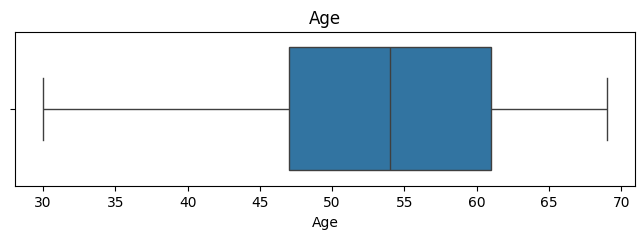

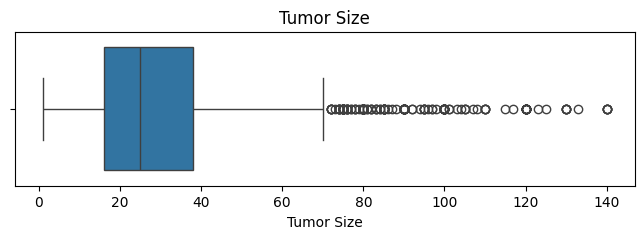

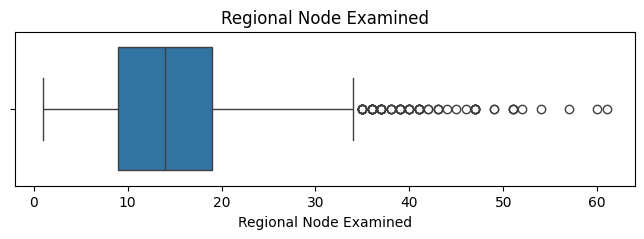

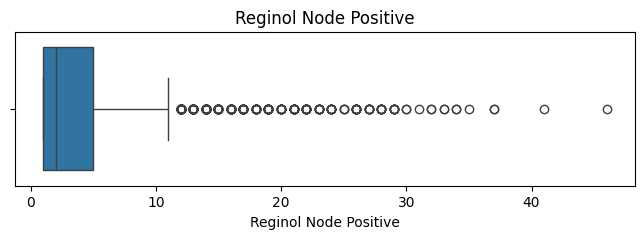

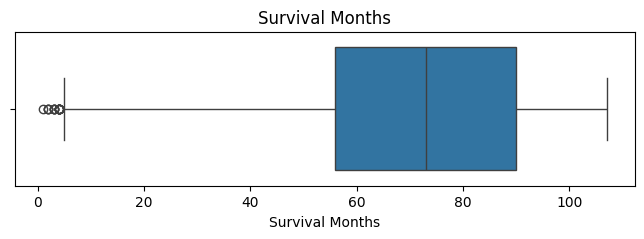

In [17]:
for column in numeric_cols:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[column]
    )

    plt.title(column)

plt.show()


## . IQR-Based Outlier Detection

In [18]:
print("="*60)
print("Outlier Summary")

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Outlier Summary
Age: 0 outliers
Tumor Size: 222 outliers
Regional Node Examined: 72 outliers
Reginol Node Positive: 344 outliers
Survival Months: 18 outliers


## Outlier Removal
Consider removing outliers only if they are likely to be measurement errors; in clinical datasets, extreme values can be clinically meaningful.

In [19]:
clean_df = df.copy()

for col in numeric_cols:

    Q1 = clean_df[col].quantile(0.25)
    Q3 = clean_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    clean_df = clean_df[
        (clean_df[col] >= lower) &
        (clean_df[col] <= upper)
    ]

print("Original Shape:", df.shape)
print("Clean Shape:", clean_df.shape)

Original Shape: (4023, 16)
Clean Shape: (3258, 16)


## Categorical Feature Distribution

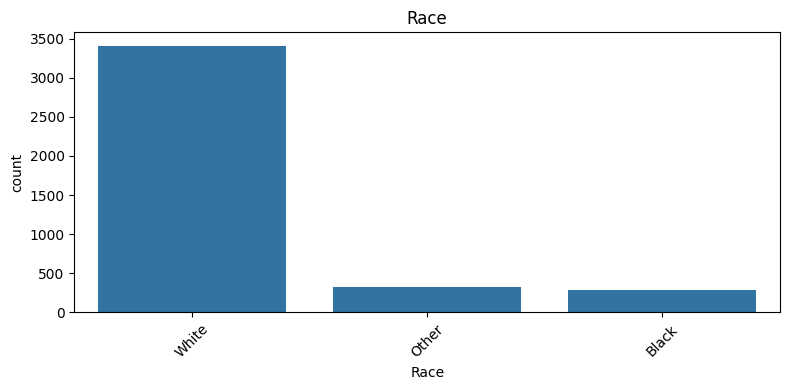

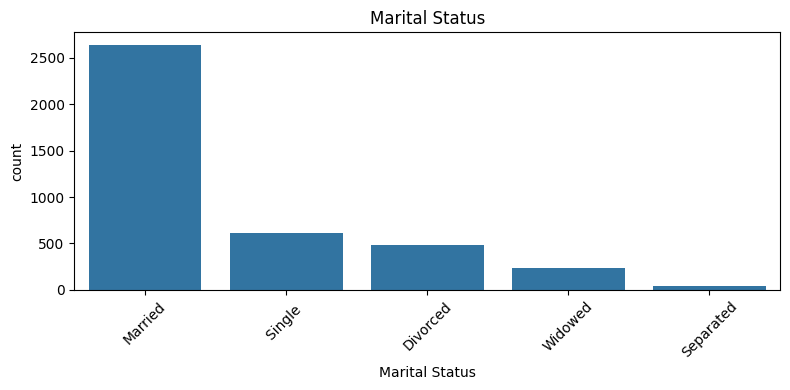

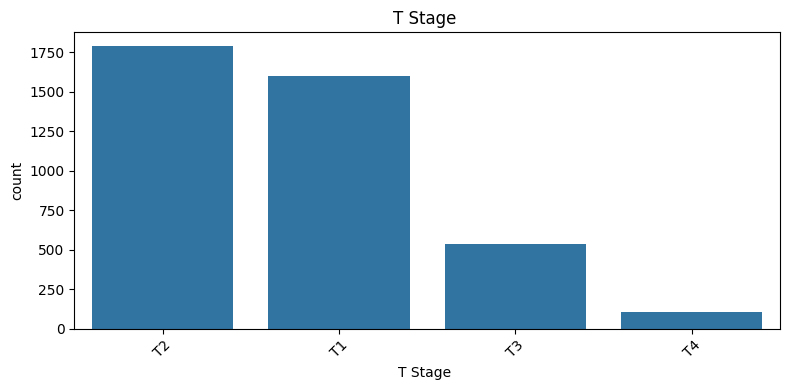

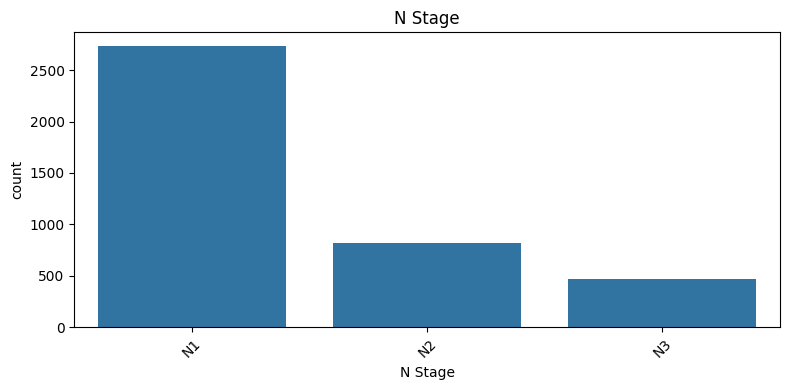

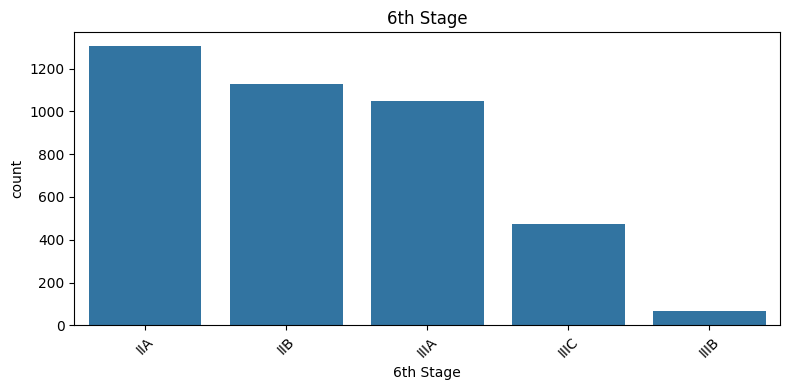

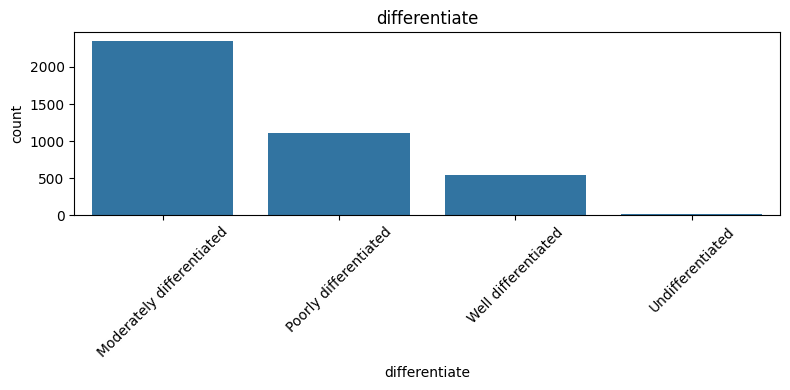

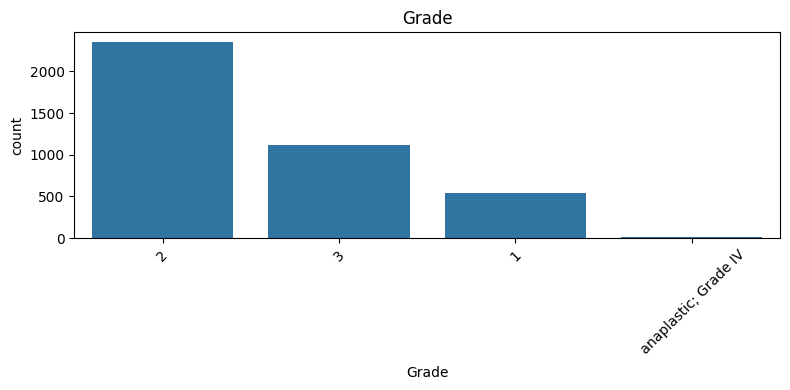

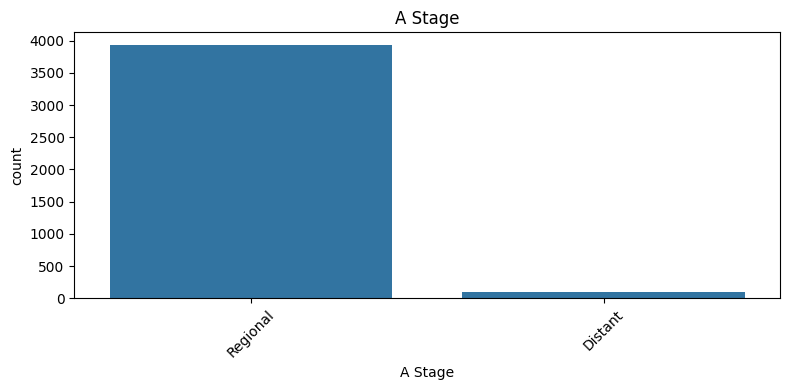

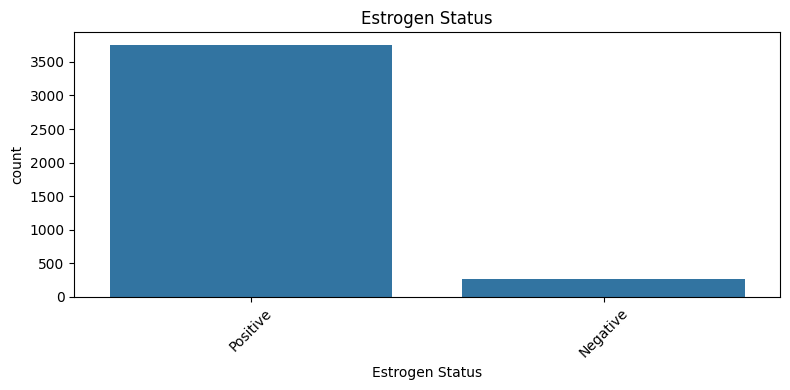

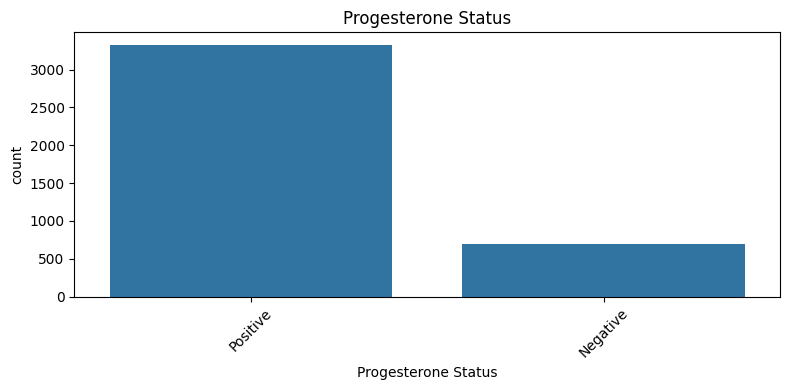

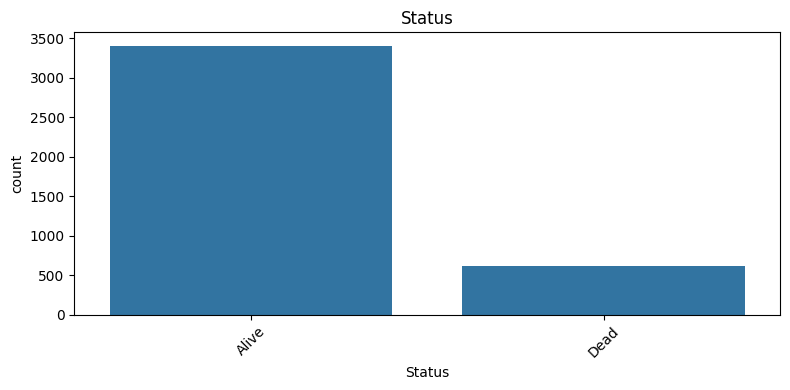

In [20]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )

    plt.xticks(rotation=45)

    plt.title(col)

    plt.tight_layout()

plt.show()


In [21]:
print(df.select_dtypes(include='object').columns)

Index(['Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Estrogen Status',
       'Progesterone Status', 'Status'],
      dtype='object')


##############################################################
# AUTOMATIC TARGET DETECTION
##############################################################

In [22]:
possible_targets = [
    'diagnosis',
    'Diagnosis',
    'target',
    'Target',
    'Class',
    'class',
    'Outcome',
    'Label'
]
target = None

for col in possible_targets:
    if col in df.columns:
        target = col
        break

if target is None:
    target = df.columns[-1]

print("\nTarget Column:", target)



Target Column: Status


In [23]:
df.dtypes

Age                        int64
Race                      object
Marital Status            object
T Stage                   object
N Stage                   object
6th Stage                 object
differentiate             object
Grade                     object
A Stage                   object
Tumor Size                 int64
Estrogen Status           object
Progesterone Status       object
Regional Node Examined     int64
Reginol Node Positive      int64
Survival Months            int64
Status                    object
dtype: object

##############################################################
# ENCODE CATEGORICAL COLUMNS
##############################################################

In [24]:
from sklearn.preprocessing import LabelEncoder
target = df.columns[-1]
X = df.drop(columns=[target])
y = df[target]

# Encode target if necessary
if y.dtype == "object":
    y = LabelEncoder().fit_transform(y)

# Encode all categorical features
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))

## Feature Correlation with the Target

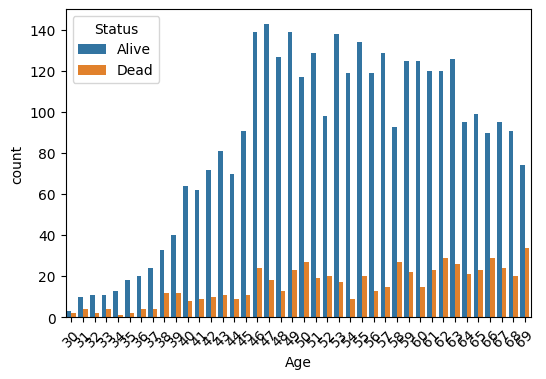

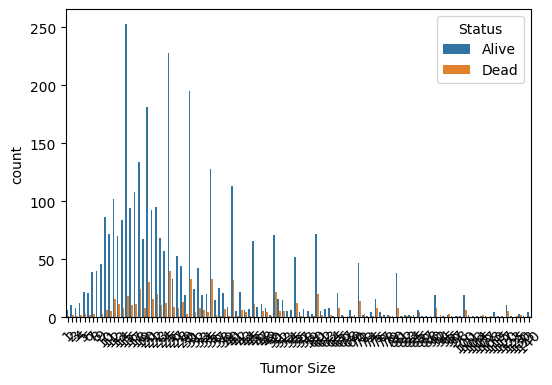

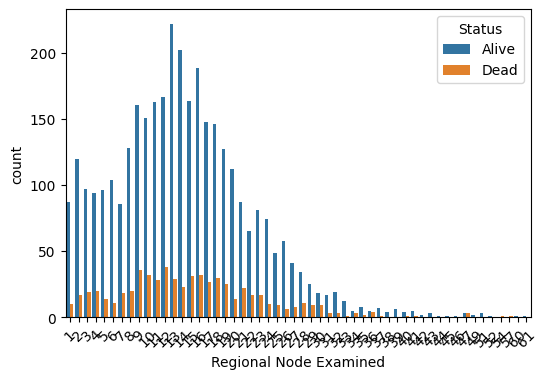

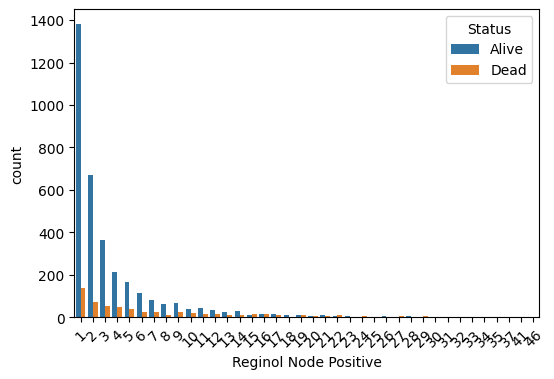

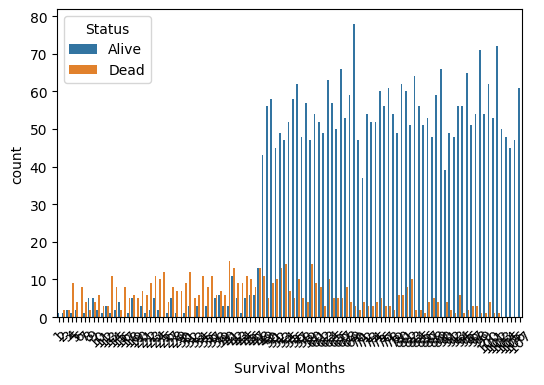

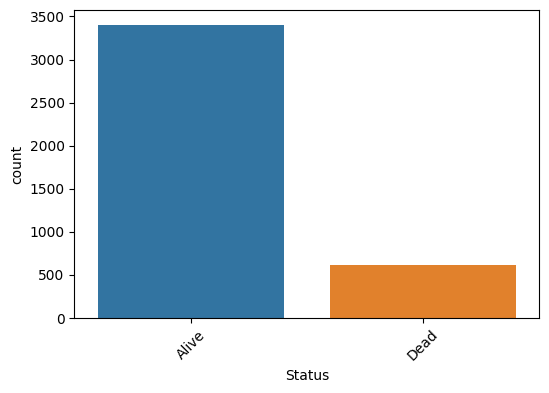

In [25]:
selected_features = [
    "Age",
    "Tumor Size",
    "Regional Node Examined",
    "Reginol Node Positive",
    "Survival Months",
    "Status"
]
for col in selected_features:

    plt.figure(figsize=(6,4))

    sns.countplot(data=df,
                  x=col,
                  hue='Status')

    plt.xticks(rotation=45)

plt.show()


##############################################################
# FEATURE SCALING
##############################################################

In [26]:
from sklearn.preprocessing import LabelEncoder

X = df.drop("Status", axis=1)
y = df["Status"]

# Encode target
y = LabelEncoder().fit_transform(y)

# Encode all categorical features
for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

In [27]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

In [28]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

##############################################################
# TRAIN TEST SPLIT
##############################################################

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


## SMOTE

In [30]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train, y_train = sm.fit_resample(
    X_train,
    y_train
)

##############################################################
# MODELS
##############################################################

In [31]:
models = {

    "Logistic Regression":
        LogisticRegression(),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Support Vector Machine":
        SVC(probability=True),

    "KNN":
        KNeighborsClassifier(),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42)
}

##############################################################
# MODEL TRAINING
##############################################################

In [32]:
results = []

best_model = None
best_accuracy = 0

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(
        y_test,
        prediction,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        prediction,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        prediction,
        average='weighted'
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print("\n", "="*60)
    print(name)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print(classification_report(y_test, prediction))

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_name = name



Logistic Regression
Accuracy : 0.7950310559006211
Precision: 0.8611939022111296
Recall   : 0.7950310559006211
F1 Score : 0.8164191196327302
              precision    recall  f1-score   support

           0       0.94      0.81      0.87       682
           1       0.41      0.73      0.52       123

    accuracy                           0.80       805
   macro avg       0.67      0.77      0.70       805
weighted avg       0.86      0.80      0.82       805


Decision Tree
Accuracy : 0.8012422360248447
Precision: 0.832240043257231
Recall   : 0.8012422360248447
F1 Score : 0.813842597961611
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       682
           1       0.39      0.54      0.46       123

    accuracy                           0.80       805
   macro avg       0.65      0.70      0.67       805
weighted avg       0.83      0.80      0.81       805


Random Forest
Accuracy : 0.8894409937888199
Precision: 0.88135403069672

##############################################################
# RESULTS TABLE
##############################################################

In [33]:
results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(results.sort_values("Accuracy", ascending=False))

                    Model  Accuracy  Precision    Recall        F1
2           Random Forest  0.889441   0.881354  0.889441  0.883699
5       Gradient Boosting  0.886957   0.886582  0.886957  0.886767
3  Support Vector Machine  0.817391   0.864096  0.817391  0.833412
1           Decision Tree  0.801242   0.832240  0.801242  0.813843
0     Logistic Regression  0.795031   0.861194  0.795031  0.816419
4                     KNN  0.742857   0.829387  0.742857  0.772234


##############################################################
# CROSS VALIDATION
##############################################################

In [34]:
print("\nCross Validation")

scores = cross_val_score(
    best_model,
    X_scaled,
    y,
    cv=10
)

print(scores)

print("Average Accuracy:", scores.mean())



Cross Validation
[0.90322581 0.89826303 0.91811414 0.90547264 0.89552239 0.89800995
 0.91044776 0.92039801 0.89800995 0.8880597 ]
Average Accuracy: 0.9035523375677444


##############################################################
# HYPERPARAMETER TUNING
##############################################################

In [35]:
print("\nHyperparameter Tuning")

parameters = {

    "n_estimators":[100,200,300],

    "max_depth":[3,5,10,None],

    "min_samples_split":[2,5,10]

}

grid = GridSearchCV(

    RandomForestClassifier(random_state=42),

    parameters,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid.fit(X_train,y_train)

print("Best Parameters")

print(grid.best_params_)

best_rf = grid.best_estimator_


Hyperparameter Tuning
Best Parameters
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}


##############################################################
# FEATURE IMPORTANCE
##############################################################

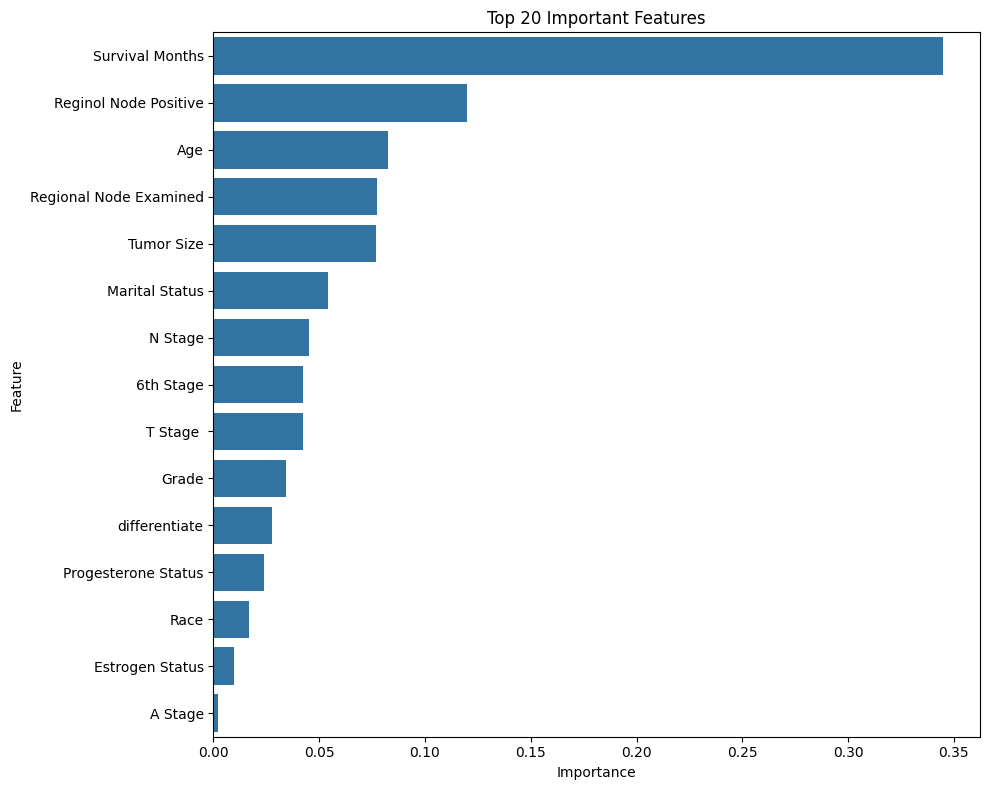

In [36]:
importance = pd.DataFrame({
    "Feature": df.drop(columns=[target]).columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(20),

    x="Importance",

    y="Feature"

)

plt.title("Top 20 Important Features")

plt.tight_layout()

plt.show()

##############################################################
# CONFUSION MATRIX
##############################################################

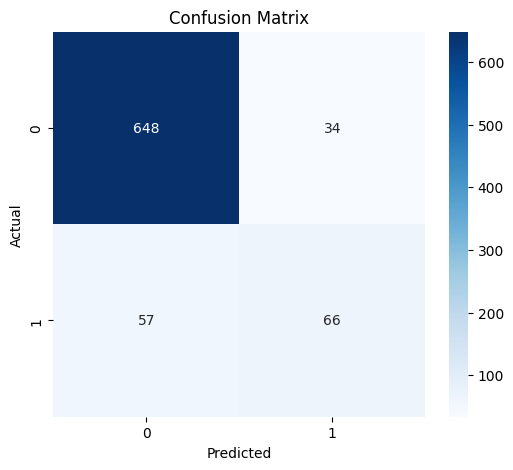

In [37]:
prediction = best_rf.predict(X_test)

cm = confusion_matrix(

    y_test,

    prediction

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap="Blues"

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

##############################################################
# ROC CURVE
##############################################################

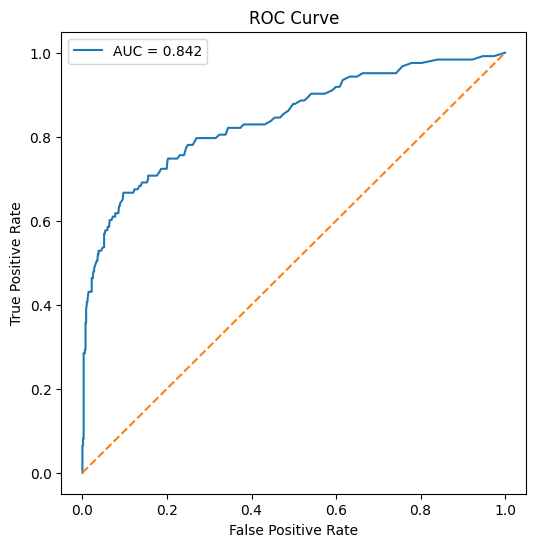

In [38]:
if len(np.unique(y))==2:

    probs = best_rf.predict_proba(X_test)[:,1]

    fpr,tpr,threshold = roc_curve(

        y_test,

        probs

    )

    roc_auc = auc(fpr,tpr)

    plt.figure(figsize=(6,6))

    plt.plot(

        fpr,

        tpr,

        label="AUC = %.3f"%roc_auc

    )

    plt.plot([0,1],[0,1],'--')

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve")

    plt.legend()

    plt.show()


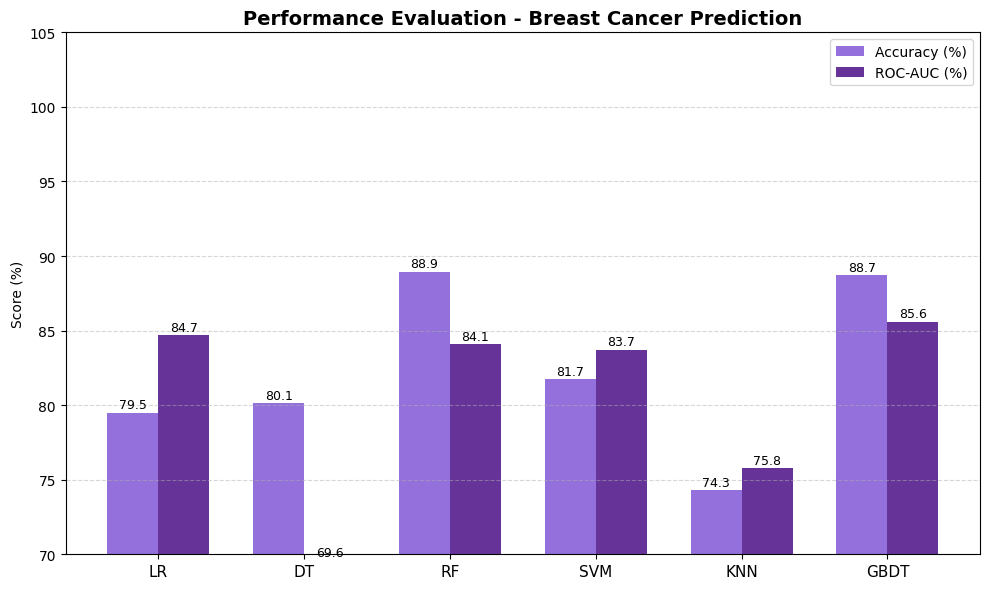

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ------------------------------------
# Calculate Accuracy and ROC-AUC
# ------------------------------------

model_labels = results["Model"].tolist()

means_accuracy = (
    results.set_index("Model")
    .loc[model_labels, "Accuracy"]
    .to_numpy() * 100
)

means_roc = []

for label in model_labels:

    model = models[label]

    # Train only if necessary
    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):

        y_score = model.predict_proba(X_test)[:, 1]

    elif hasattr(model, "decision_function"):

        y_score = model.decision_function(X_test)

    else:

        means_roc.append(np.nan)
        continue

    fpr, tpr, _ = roc_curve(y_test, y_score)

    means_roc.append(auc(fpr, tpr) * 100)

means_roc = np.array(means_roc)

# ------------------------------------
# Short labels
# ------------------------------------

short_labels = {
    "Logistic Regression": "LR",
    "Decision Tree": "DT",
    "Random Forest": "RF",
    "Support Vector Machine": "SVM",
    "KNN": "KNN",
    "Gradient Boosting": "GBDT",
}

x_labels = [short_labels.get(name, name) for name in model_labels]

# ------------------------------------
# Plot
# ------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

index = np.arange(len(model_labels))
bar_width = 0.35

bars1 = ax.bar(
    index,
    means_accuracy,
    width=bar_width,
    color="mediumpurple",
    label="Accuracy (%)"
)

bars2 = ax.bar(
    index + bar_width,
    means_roc,
    width=bar_width,
    color="rebeccapurple",
    label="ROC-AUC (%)"
)

# ------------------------------------
# Add value labels
# ------------------------------------

for bar in bars1:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.1f}",
        ha="center",
        fontsize=9
    )

for bar in bars2:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.1f}",
        ha="center",
        fontsize=9
    )

# ------------------------------------
# Formatting
# ------------------------------------

ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(x_labels, fontsize=11)

ax.set_ylim(70, 105)

ax.set_ylabel("Score (%)")

ax.set_title(
    "Performance Evaluation - Breast Cancer Prediction",
    fontsize=14,
    weight="bold"
)

ax.legend()

ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig(
    "PE_breast_cancer.jpeg",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

In [40]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy='auto',
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Original Training Shape:")
print(X_train.shape)

print("\nBalanced Training Shape:")
print(X_train_smote.shape)

Original Training Shape:
(5450, 15)

Balanced Training Shape:
(5450, 15)


##############################################################
## SAVE RESULTS
##############################################################

In [41]:
results.to_csv(

    "Model_Comparison.csv",

    index=False

)

importance.to_csv(

    "Feature_Importance.csv",

    index=False

)

print("Results Saved.")


Results Saved.


##############################################################
# Best Model & Best Accuracy 
##############################################################

In [42]:
print("="*60)

print("BEST MODEL :", best_name)

print("BEST ACCURACY :", best_accuracy)

print("="*60)

BEST MODEL : Random Forest
BEST ACCURACY : 0.8894409937888199


In [43]:
import os

folders = [
    "images",
    "models",
    "results",
    "reports"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


##############################################################
# SAVE MODEL
##############################################################

In [44]:
import joblib

random_forest = models["Random Forest"]
logistic_model = models["Logistic Regression"]

joblib.dump(
    random_forest,
    "models/RandomForest.pkl"
)

joblib.dump(
    logistic_model,
    "models/LogisticRegression.pkl"
)
joblib.dump(
    best_rf,
    "models/Best_Model.pkl"
)

['models/Best_Model.pkl']

In [45]:
import os

print(os.getcwd())

/kaggle/working
